# Degrees of freedom -> heat capacity -> the speed of sound
### count the ways a molecule holds energy, and everything else follows

Equipartition: every independent **quadratic** way a molecule stores energy -- each velocity
component, each rotation, each vibration (kinetic *and* potential) -- carries on average
$\tfrac12 kT$. So the total is $(f/2)kT$ and the molar heat capacities are
$$C_v=\tfrac{f}{2}R,\qquad C_p=C_v+R,\qquad \gamma=\frac{C_p}{C_v}=\frac{f+2}{f}.$$
Counting $f$ is the whole game. This notebook, using `dgs/degrees_of_freedom.py`, shows the DOF
breakdown per molecule, how $\gamma$ follows, the temperature **staircase** as rotations and
vibrations switch on, and the payoff you can hear -- the speed of sound
$c=\sqrt{\gamma RT/M}$ depends directly on $\gamma$. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import degrees_of_freedom as dof
R = dof.R_GAS
print("gamma: mono %.3f, diatomic %.3f, nonlinear %.3f" %
      (dof.heat_capacity_ratio(3), dof.heat_capacity_ratio(5), dof.heat_capacity_ratio(6)))

gamma: mono 1.667, diatomic 1.400, nonlinear 1.333


## 1. Where the degrees of freedom come from

Every molecule gets **3 translational** DOF. A diatomic adds **2 rotational** (spin about the two
axes across the bond); a bent/nonlinear molecule adds **3**. Vibrations, when active, add **2 per
mode** (kinetic + potential). Stack them up:

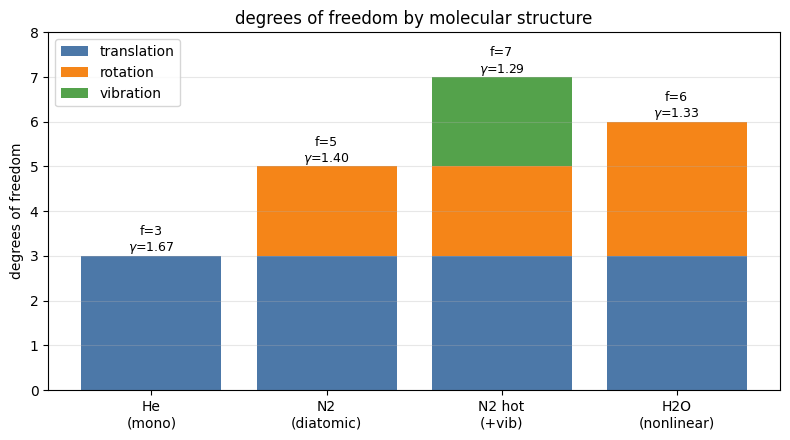

In [2]:
mols = ["He\n(mono)", "N2\n(diatomic)", "N2 hot\n(+vib)", "H2O\n(nonlinear)"]
trans = [3, 3, 3, 3]
rot   = [0, 2, 2, 3]
vib   = [0, 0, 2, 0]
f_tot = [dof.molecular_dof(1), dof.molecular_dof(2), dof.molecular_dof(2, vibrational=True),
         dof.molecular_dof(3, linear=False)]
xpos = np.arange(len(mols))
plt.figure(figsize=(8, 4.5))
plt.bar(xpos, trans, label="translation", color="#4C78A8")
plt.bar(xpos, rot, bottom=trans, label="rotation", color="#F58518")
plt.bar(xpos, vib, bottom=np.array(trans)+np.array(rot), label="vibration", color="#54A24B")
for i, f in enumerate(f_tot):
    plt.text(i, f+0.1, f"f={f}\n$\\gamma$={dof.heat_capacity_ratio(f):.2f}", ha="center", fontsize=9)
plt.xticks(xpos, mols); plt.ylabel("degrees of freedom"); plt.ylim(0, 8)
plt.title("degrees of freedom by molecular structure"); plt.legend()
plt.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

## 2. $\gamma$ falls straight out of $f$

More degrees of freedom means energy is spread thinner per unit temperature, so $\gamma=(f+2)/f$
drops toward 1. The measured values -- helium 1.66, air 1.40, steam ~1.33 -- land right on the
curve at their DOF counts.

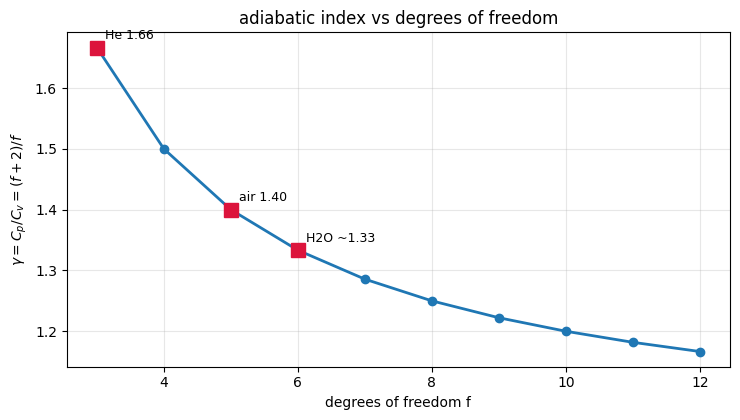

In [3]:
fs = np.arange(3, 13)
plt.figure(figsize=(7.5, 4.3))
plt.plot(fs, [dof.heat_capacity_ratio(f) for f in fs], "o-", lw=2)
for f, name, g in [(3, "He 1.66", 5/3), (5, "air 1.40", 1.4), (6, "H2O ~1.33", 4/3)]:
    plt.plot(f, g, "s", ms=10, color="crimson")
    plt.annotate(name, (f, g), textcoords="offset points", xytext=(6, 6), fontsize=9)
plt.xlabel("degrees of freedom f"); plt.ylabel("$\\gamma=C_p/C_v=(f+2)/f$")
plt.title("adiabatic index vs degrees of freedom"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. The heat-capacity staircase: DOF freeze out at low T

Equipartition is the *classical* (high-T) answer. Quantum mechanics makes each mode **switch on**
only once $kT$ exceeds its energy spacing. So a diatomic's $C_v$ climbs in steps: translation is
always there ($\tfrac32 R$), rotation turns on around its rotational temperature, and vibration
only at very high $T$. Model each mode with the Einstein function $E(\Theta/T)$ (0 when cold, 1
when hot) -- for hydrogen ($\Theta_{rot}\approx85$ K, $\Theta_{vib}\approx6000$ K) you get the
famous $\tfrac32\to\tfrac52\to\tfrac72$ staircase.

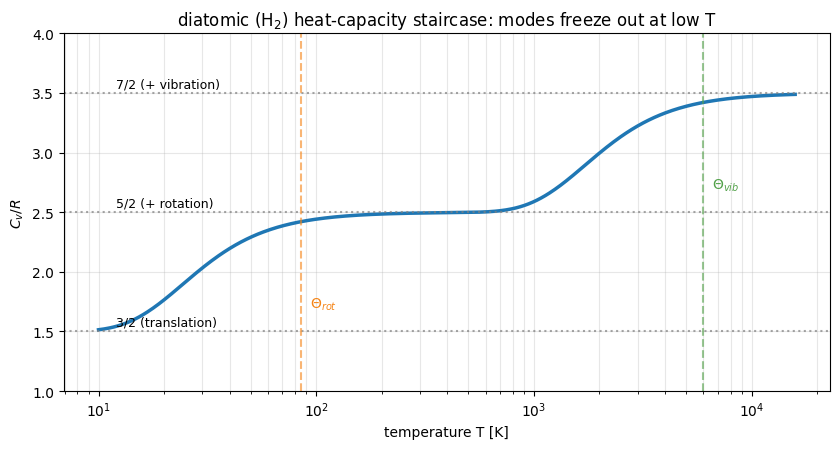

at room T (~300 K), C_v/R = 2.49 (rotation on, vibration still frozen -> gamma~1.4)


In [4]:
def einstein(T, Theta):
    # E(x) = x^2 e^x/(e^x-1)^2 = x^2/(4 sinh^2(x/2)); -> 1 hot, -> 0 cold.
    # sinh form avoids the e^x overflow at very low T (huge x).
    x = Theta / np.asarray(T, float)
    return np.where(x < 30, x**2 / (4 * np.sinh(np.clip(x, 0, 30) / 2)**2), 0.0)

T = np.logspace(1, 4.2, 500)      # 10 K to ~16000 K
Th_rot, Th_vib = 85.0, 6000.0
Cv_over_R = 1.5 + einstein(T, Th_rot) + einstein(T, Th_vib)   # trans + rot + vib
plt.figure(figsize=(8.5, 4.6))
plt.semilogx(T, Cv_over_R, lw=2.5)
for lvl, lab in [(1.5, "3/2 (translation)"), (2.5, "5/2 (+ rotation)"), (3.5, "7/2 (+ vibration)")]:
    plt.axhline(lvl, color="gray", ls=":", alpha=0.7); plt.text(12, lvl+0.05, lab, fontsize=9)
plt.axvline(Th_rot, color="#F58518", ls="--", alpha=0.6); plt.text(Th_rot*1.1, 1.7, "$\\Theta_{rot}$", color="#F58518")
plt.axvline(Th_vib, color="#54A24B", ls="--", alpha=0.6); plt.text(Th_vib*1.1, 2.7, "$\\Theta_{vib}$", color="#54A24B")
plt.xlabel("temperature T [K]"); plt.ylabel("$C_v / R$"); plt.ylim(1, 4)
plt.title("diatomic (H$_2$) heat-capacity staircase: modes freeze out at low T")
plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()
print("at room T (~300 K), C_v/R = %.2f (rotation on, vibration still frozen -> gamma~1.4)"
      % (1.5 + einstein(300, Th_rot) + einstein(300, Th_vib)))

## 4. Acoustic algebra: the speed of sound is $\sqrt{\gamma RT/M}$

Sound is an adiabatic compression wave, so its speed carries $\gamma$ -- and $\gamma$ came from the
degrees of freedom. Air ($\gamma=1.40$) gives $343$ m/s at $20^\circ$C; helium (monatomic,
$\gamma=1.67$, and light) gives $\sim1000$ m/s, which is why breathing it raises your voice's
pitch. Same temperature, different molecule -> different sound.

gas          f   gamma   M[kg/mol]   speed of sound @20C
  air (N2/O2)  5  1.400   0.02896   343 m/s
  helium       3  1.667   0.00400   1007 m/s
  argon        3  1.667   0.03995   319 m/s
  CO2          5  1.400   0.04401   278 m/s


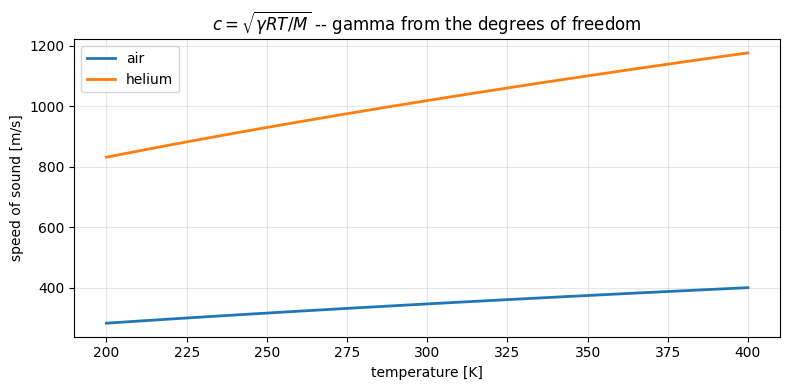

In [5]:
def sound_speed(gamma, M, T=293.15):
    return np.sqrt(gamma * R * T / M)
gases = [("air (N2/O2)", 5, 0.02896), ("helium", 3, 0.004003),
         ("argon", 3, 0.039948), ("CO2", 5, 0.04401)]
print("gas          f   gamma   M[kg/mol]   speed of sound @20C")
for name, f, M in gases:
    g = dof.heat_capacity_ratio(f)
    print(f"  {name:12s} {f}  {g:.3f}   {M:.5f}   {sound_speed(g, M):.0f} m/s")
Ts = np.linspace(200, 400, 100)
plt.figure(figsize=(8, 4))
for name, f, M in [("air", 5, 0.02896), ("helium", 3, 0.004003)]:
    plt.plot(Ts, sound_speed(dof.heat_capacity_ratio(f), M, Ts), lw=2, label=name)
plt.xlabel("temperature [K]"); plt.ylabel("speed of sound [m/s]")
plt.title("$c=\\sqrt{\\gamma RT/M}$ -- gamma from the degrees of freedom"); plt.legend()
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## What we did

* **Count the degrees of freedom** (3 translation + rotation + vibration) and $C_v=(f/2)R$,
  $\gamma=(f+2)/f$ follow -- helium 1.67, air 1.40, steam 1.33.
* Quantum mechanics **freezes out** cold modes, so $C_v$ climbs a $\tfrac32\to\tfrac52\to\tfrac72$
  **staircase** as rotation then vibration switch on.
* The speed of sound $c=\sqrt{\gamma RT/M}$ inherits $\gamma$ from the DOF -- helium's high
  $\gamma$ and low mass make it fast (the squeaky-voice effect).

The thermal thread: same $\tfrac12 kT$-per-DOF as `dgs/maxwell_boltzmann.py` (3 translational give
$\langle KE\rangle=\tfrac32 kT$) and the same Boltzmann/Einstein factor as `dgs/quantum_oscillator.py`.